In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

https://github.com/samcw/ResNet18-Pytorch/blob/master/ResNet18.ipynb

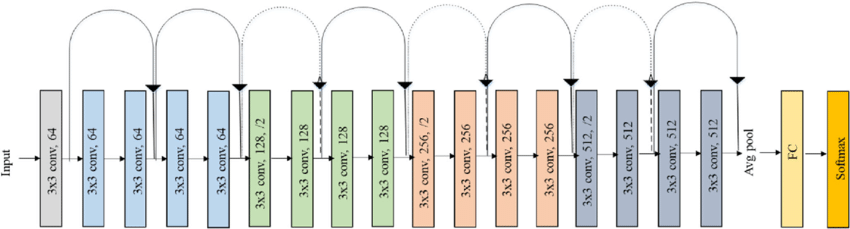

In [2]:
class ResidualBlock(nn.Module):
    def __init__(self, inchannel, outchannel, stride=1):
        super(ResidualBlock, self).__init__()
        self.left = nn.Sequential(
            nn.Conv2d(inchannel, outchannel, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(outchannel),
            nn.ReLU(inplace=True),
            nn.Conv2d(outchannel, outchannel, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(outchannel)
        )
        self.shortcut = nn.Sequential()
        if stride != 1 or inchannel != outchannel:
            self.shortcut = nn.Sequential(
                nn.Conv2d(inchannel, outchannel, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(outchannel)
            )

    def forward(self, x):
        out = self.left(x)
        out = out + self.shortcut(x)
        out = F.relu(out)

        return out

class ResNet(nn.Module):
    def __init__(self, ResidualBlock, num_classes=10):
        super(ResNet, self).__init__()
        self.inchannel = 64
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.layer1 = self.make_layer(ResidualBlock, 64, 2, stride=1)
        self.layer2 = self.make_layer(ResidualBlock, 128, 2, stride=2)
        self.layer3 = self.make_layer(ResidualBlock, 256, 2, stride=2)
        self.layer4 = self.make_layer(ResidualBlock, 512, 2, stride=2)
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, block, channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.inchannel, channels, stride))
            self.inchannel = channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

In [3]:
def ResNet18():
    return ResNet(ResidualBlock)

Loading CIFAR-10 from Google Drive (no torchvision download)

Uses the **CIFAR-10 python version** (`cifar-10-python.tar.gz`, 163 MB, md5 `c58f30108f718f92721af3b95e74349a`).
Set `DRIVE_TAR` to wherever the archive sits in your Drive. `CIFAR10Local` is a drop-in replacement for
`torchvision.datasets.CIFAR10` — same `__getitem__` contract, same `classes` / `class_to_idx`.

In [12]:
import os, pickle, tarfile, zipfile
import numpy as np
from PIL import Image
import torch

# ---- Mount Google Drive (skip if running locally) ----
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print("Not on Colab - make sure DRIVE_TAR points to a local path")

# ---- Path to the CIFAR-10 *python version* archive in your Drive ----
DRIVE_TAR   = '/content/drive/MyDrive/CIFAR10.zip'
# EXTRACT_DIR is where the initial archive (e.g., ZIP) will be extracted
EXTRACT_DIR = '../data'
# Final_data_root is where the actual 'cifar-10-batches-py' folder should reside
FINAL_DATA_ROOT_NAME = 'cifar-10-batches-py'

# Ensure EXTRACT_DIR exists
os.makedirs(EXTRACT_DIR, exist_ok=True)

# Determine the final data_root path
data_root = os.path.join(EXTRACT_DIR, FINAL_DATA_ROOT_NAME)

# Check if the final data_root (cifar-10-batches-py) already exists and contains data files
if not (os.path.isdir(data_root) and any(f.startswith('data_batch_') for f in os.listdir(data_root))):
    print("CIFAR-10 data not found in final expected location, proceeding with extraction.")

    # First, extract the main archive (e.g., .zip)
    temp_extract_path = EXTRACT_DIR # Use EXTRACT_DIR for initial extraction
    if DRIVE_TAR.endswith('.zip'):
        print(f"Extracting ZIP file: {DRIVE_TAR} into {temp_extract_path}")
        with zipfile.ZipFile(DRIVE_TAR, 'r') as zip_ref:
            zip_ref.extractall(temp_extract_path)
    elif DRIVE_TAR.endswith('.tar.gz'):
        print(f"Extracting TAR.GZ file: {DRIVE_TAR} into {temp_extract_path}")
        with tarfile.open(DRIVE_TAR, 'r:gz') as tar:
            tar.extractall(temp_extract_path)
    else:
        print(f"Unsupported archive format for {DRIVE_TAR}. Please use .zip or .tar.gz")
        raise ValueError("Unsupported archive format")

    # After initial extraction, find the tar.gz file and extract it
    # We need to search in the temp_extract_path and any subdirectories created by the zip
    found_tar_gz = None
    for root, _, files in os.walk(temp_extract_path):
        for file in files:
            if file == 'cifar-10-python.tar.gz':
                found_tar_gz = os.path.join(root, file)
                break
        if found_tar_gz:
            break

    if found_tar_gz:
        print(f"Found and extracting nested TAR.GZ file: {found_tar_gz} into {EXTRACT_DIR}")
        with tarfile.open(found_tar_gz, 'r:gz') as tar:
            tar.extractall(EXTRACT_DIR) # Extract the content of tar.gz to EXTRACT_DIR
        # Now the 'cifar-10-batches-py' folder should be directly in EXTRACT_DIR
    else:
        # If no tar.gz found, but data batches might be directly in a subfolder
        # This block tries to find the 'cifar-10-batches-py' after unzipping
        possible_data_roots = [
            os.path.join(temp_extract_path, FINAL_DATA_ROOT_NAME),
            temp_extract_path # Data batches might be directly in EXTRACT_DIR
        ]
        # Also check one level deeper for the case where zip contains a single folder which then contains the data
        extracted_contents = os.listdir(temp_extract_path)
        if len(extracted_contents) == 1 and os.path.isdir(os.path.join(temp_extract_path, extracted_contents[0])):
             possible_data_roots.append(os.path.join(temp_extract_path, extracted_contents[0], FINAL_DATA_ROOT_NAME))
             possible_data_roots.append(os.path.join(temp_extract_path, extracted_contents[0]))

        found_final_data_root = False
        for p_root in possible_data_roots:
            if os.path.isdir(p_root) and any(f.startswith('data_batch_') for f in os.listdir(p_root)):
                data_root = p_root
                found_final_data_root = True
                break
        if not found_final_data_root:
            raise FileNotFoundError(f"Could not locate CIFAR-10 data files (e.g., data_batch_1) after extraction in {temp_extract_path}. Contents: {os.listdir(temp_extract_path)}")
else:
    print(f"CIFAR-10 data found at {data_root}, skipping extraction.")

# Final check after all attempts
if not (os.path.isdir(data_root) and any(f.startswith('data_batch_') for f in os.listdir(data_root))):
    raise RuntimeError(f"Failed to locate CIFAR-10 data batches in {data_root}. Please verify your archive content and path.")

print("Data at:", data_root, "->", sorted(os.listdir(data_root)))

def _unpickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f, encoding='bytes')

class CIFAR10Local(torch.utils.data.Dataset):
    """Drop-in replacement for torchvision.datasets.CIFAR10 that reads the
    extracted python-version batch files instead of downloading."""
    def __init__(self, root, train=True, transform=None):
        self.transform = transform
        files = [f'data_batch_{i}' for i in range(1, 6)] if train else ['test_batch']

        imgs, labels = [], []
        for fname in files:
            d = _unpickle(os.path.join(root, fname))
            imgs.append(d[b'data'])
            labels += d[b'labels']

        # (N, 3072) flat -> (N, 32, 32, 3) HWC uint8
        self.data = np.concatenate(imgs).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
        self.targets = labels

        meta = _unpickle(os.path.join(root, 'batches.meta'))
        self.classes = [c.decode('utf-8') for c in meta[b'label_names']]
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        img = Image.fromarray(self.data[idx])      # PIL, so RandomCrop/Flip work
        if self.transform is not None:
            img = self.transform(img)
        return img, self.targets[idx]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CIFAR-10 data not found in final expected location, proceeding with extraction.
Extracting ZIP file: /content/drive/MyDrive/CIFAR10.zip into ../data
Found and extracting nested TAR.GZ file: ../data/CIFAR10/cifar-10-python.tar.gz into ../data


/tmp/ipykernel_894/2262008011.py:58: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(EXTRACT_DIR) # Extract the content of tar.gz to EXTRACT_DIR


Data at: ../data/cifar-10-batches-py -> ['batches.meta', 'data_batch_1', 'data_batch_2', 'data_batch_3', 'data_batch_4', 'data_batch_5', 'readme.html', 'test_batch']


In [13]:
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import argparse
import os

#check gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#set hyperparameter
EPOCH = 3
pre_epoch = 0
BATCH_SIZE = 128
LR = 0.01

#prepare dataset and preprocessing
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

trainset = CIFAR10Local(data_root, train=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

testset = CIFAR10Local(data_root, train=False, transform=transform_test)
print(len(trainset), "train images |", len(testset), "test images")
testloader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

#labels in CIFAR10
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

#define ResNet18
net = ResNet18().to(device)

#define loss funtion & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)

50000 train images | 10000 test images


In [14]:
#train
for epoch in range(pre_epoch, EPOCH):
    print('\nEpoch: %d' % (epoch + 1))
    net.train()
    sum_loss = 0.0
    correct = 0.0
    total = 0.0
    for i, data in enumerate(trainloader, 0):
        #prepare dataset
        length = len(trainloader)
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        #forward & backward
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        #print ac & loss in each batch
        sum_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += predicted.eq(labels.data).cpu().sum()
        print('[epoch:%d, iter:%d] Loss: %.03f | Acc: %.3f%% '
              % (epoch + 1, (i + 1 + epoch * length), sum_loss / (i + 1), 100. * correct / total))

    #get the ac with testdataset in each epoch
    print('Waiting Test...')
    with torch.no_grad():
        correct = 0
        total = 0
        for data in testloader:
            net.eval()
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum()
        print('Test\'s ac is: %.3f%%' % (100 * correct / total))

print('Train has finished, total epoch is %d' % EPOCH)


Epoch: 1
[epoch:1, iter:1] Loss: 2.364 | Acc: 9.375% 
[epoch:1, iter:2] Loss: 2.351 | Acc: 11.328% 
[epoch:1, iter:3] Loss: 2.323 | Acc: 13.281% 
[epoch:1, iter:4] Loss: 2.333 | Acc: 12.891% 
[epoch:1, iter:5] Loss: 2.339 | Acc: 12.188% 
[epoch:1, iter:6] Loss: 2.314 | Acc: 12.500% 
[epoch:1, iter:7] Loss: 2.299 | Acc: 12.946% 
[epoch:1, iter:8] Loss: 2.284 | Acc: 13.281% 
[epoch:1, iter:9] Loss: 2.258 | Acc: 14.236% 
[epoch:1, iter:10] Loss: 2.249 | Acc: 14.297% 
[epoch:1, iter:11] Loss: 2.242 | Acc: 14.773% 
[epoch:1, iter:12] Loss: 2.227 | Acc: 15.169% 
[epoch:1, iter:13] Loss: 2.217 | Acc: 15.385% 
[epoch:1, iter:14] Loss: 2.212 | Acc: 15.904% 
[epoch:1, iter:15] Loss: 2.196 | Acc: 16.771% 
[epoch:1, iter:16] Loss: 2.188 | Acc: 16.992% 
[epoch:1, iter:17] Loss: 2.186 | Acc: 17.371% 
[epoch:1, iter:18] Loss: 2.180 | Acc: 17.708% 
[epoch:1, iter:19] Loss: 2.173 | Acc: 18.215% 
[epoch:1, iter:20] Loss: 2.159 | Acc: 18.789% 
[epoch:1, iter:21] Loss: 2.158 | Acc: 18.824% 
[epoch:1, ite